# Full Diagnosis Model

* A classification model that predicts HeartDisease using all available features

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


In [2]:
df = pd.read_csv("../Data/Raw/heart_disease.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:


X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# training the model
model_pipeline.fit(X_train, y_train)

# Predicting 
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion matrix:
 [[68 14]
 [ 7 95]]

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184


ROC-AUC: 0.9307747489239598


0 = Healthy 

1 = Diseased

68 → True Negatives (healthy correctly predicted)

95 → True Positives (disease correctly predicted)

14 → False Positives (healthy predicted as sick)

7 → False Negatives (sick predicted as healthy)

* True positives -> correctly detected diseases

* False negatives -> dangerous mistakes

The final diagnostic model achieved an accuracy of 89% and a ROC-AUC of 0.93, indicating excellent ability to distinguish between healthy patients and those with heart disease.

The confusion matrix shows that the model correctly identified 95 patients with heart disease, while only 7 cases were missed (false negatives). This corresponds to a recall of 0.93 for the positive class, meaning the model successfully detects 93% of patients with heart disease.

Although 14 healthy patients were incorrectly classified as diseased, this trade-off is acceptable in a medical screening context, where missing a diagnosis is significantly more critical than raising false alarms.

Overall, the model demonstrates strong performance and is suitable as the final stage in the proposed multi-step diagnostic pipeline.

In [20]:
# computing PR

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

pr_auc = average_precision_score(y_test, y_prob)

print("PR-AUC:", pr_auc)

PR-AUC: 0.9375996167075055


## PR Curve plot

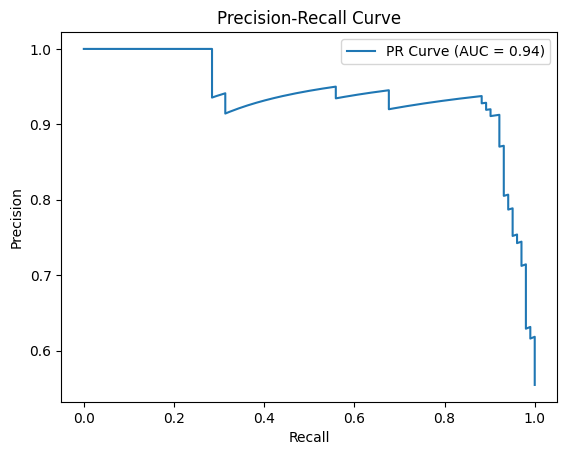

In [21]:
plt.figure()

plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

The Precision-Recall curve was analyzed to better understand the trade-off between recall and precision for detecting heart disease. The model achieved a PR-AUC of approximately 0.94, indicating excellent performance in identifying positive cases while maintaining high precision.

The curve shows that high recall levels (around 0.9) can be achieved while maintaining precision close to 0.9, confirming that lowering the classification threshold improves disease detection without introducing excessive false positives.

In [ ]:
target_recall = 0.93  

valid = np.where(recall[:-1] >= target_recall)[0] 

if len(valid) == 0:
    print("No threshold achieves the target recall.")
else:
    
    best_i = valid[np.argmax(precision[valid])]
    best_thr = thresholds[best_i]

    print("Best Threshold (recall constraint):", best_thr)
    print("Precision:", precision[best_i])
    print("Recall:", recall[best_i])

Best Threshold (recall constraint): 0.5447916538927844
Precision: 0.8715596330275229
Recall: 0.9313725490196079


The model is operating at a point where:

* False negatives are minimized

* False positives remain acceptable

The Precision-Recall analysis was used to determine an appropriate probability threshold for classification. Instead of maximizing the F1-score alone, a threshold was selected that guarantees high recall while maintaining acceptable precision.

A threshold of approximately 0.54 achieves a recall of 0.93, meaning the model correctly detects 93% of heart disease cases, while maintaining a precision of 0.87. This balance minimizes missed diagnoses while keeping the number of false positives manageable, which is desirable in a medical screening system.